In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("powerplant_data.csv")

1. DATA         → load, explore, clean
2. PREPROCESS   → scale, split, convert to tensors
3. MODEL        → define architecture (your ANN class)
4. TRAINING     → loss, optimizer, training loop
5. EVALUATE     → val loss, metrics, plots
6. SAVE/LOAD    → best model checkpoint

In [3]:
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [4]:
from sklearn.model_selection import train_test_split

In [5]:
X = df.drop(columns = "PE")
X.head()

,AT,V,AP,RH
0,8.34,40.77,1010.84,90.01
1,23.64,58.49,1011.40,74.20
2,29.74,56.90,1007.15,41.91
3,19.07,49.69,1007.22,76.79
4,11.80,40.66,1017.13,97.20


In [6]:
y = df["PE"]
y.head()

0    480.48
1    445.75
2    438.76
3    453.09
4    464.43
Name: PE, dtype: float64

In [7]:
X_tr , X_te , y_tr , y_te = train_test_split(X,y, test_size = 0.2 , random_state =42)

In [8]:
from sklearn.preprocessing import StandardScaler

In [9]:
sc = StandardScaler()

In [10]:
X_tr_sc = sc.fit_transform(X_tr)
X_te_sc = sc.transform(X_te)

In [11]:
import torch
import torch.nn as nn

In [12]:
X_tr_tensor = torch.tensor(X_tr_sc,dtype = torch.float32)
X_te_tensor = torch.tensor(X_te_sc,dtype = torch.float32)

y_tr_tensor = torch.tensor(y_tr.values , dtype = torch.float32).view(-1,1)
y_te_tensor = torch.tensor(y_te.values , dtype = torch.float32).view(-1,1)

In [13]:
from torch.utils.data import DataLoader,TensorDataset

In [14]:
#Data like in TestBook
train_dataset = TensorDataset(X_tr_tensor,y_tr_tensor)
test_dataset = TensorDataset(X_te_tensor,y_te_tensor)

In [16]:
#Taking the data TensorDataset
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

### Defining the model


In [20]:
class ANN(nn.Module):
    def __init__(self):
        super().__init__() #Saying Module to run first (get prepared)

        self.model = nn.Sequential(
        nn.Linear(X_tr.shape[1],6),
        nn.ReLU(),

        nn.Linear(6,6),
        nn.ReLU(),

        nn.Linear(6,1),
    )
    def forward(self,x):
        return self.model(x)

In [22]:
import torch.optim as optim

In [23]:
model = ANN()

In [27]:
loss = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

In [33]:
X_tr_tensor

tensor([[ 0.7481,  0.7201, -0.3266, -0.4971],
        [ 0.8618,  1.2652, -0.9852,  0.8182],
        [ 0.9341,  1.5231,  0.3252,  0.8017],
        ...,
        [-0.2210, -0.8350,  0.3676, -0.8355],
        [ 0.9475,  1.1425, -0.4197, -0.4546],
        [-1.7736, -1.1905,  1.9252,  0.9184]])

In [49]:
#Training

train_loss = []
eval_loss = []

best_eval_loss = float("inf")

epochs = 100

for epoch in range(epochs):
    model.train()
    running_loss = 0.0 #Total training loss for each epoch

    #Training
    for xb,yb in train_loader:
        optimizer.zero_grad() #optimizer accumulates gradients so we use this for making it zero again

        outputs = model(xb)
        ls = loss(outputs,yb)
        ls.backward()
        optimizer.step()

        running_loss += ls.item()

    epoch_train_loss = running_loss/len(train_loader)
    train_loss.append(epoch_train_loss)


     # Validation
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad(): # no gradients compute
        for xb, yb in test_loader:
            outputs = model(xb)
            ls = loss(outputs, yb)
            running_val_loss += ls.item()

    epoch_val_loss = running_val_loss / len(test_loader)
    eval_loss.append(epoch_val_loss)

    print(f"epoch {epoch+1}/{epochs} ==> train loss = {epoch_train_loss} & val loss = {epoch_val_loss}")

    if epoch_val_loss < best_eval_loss:
        best_eval_loss = epoch_val_loss
        torch.save(model.state_dict(), "best_model.pt") #.pt or .pth

epoch 1/100 ==> train loss = 21.292010450363158 & val loss = 19.542945861816406
epoch 2/100 ==> train loss = 21.491013226906457 & val loss = 20.51381492614746
epoch 3/100 ==> train loss = 21.284638345241547 & val loss = 19.929418563842773
epoch 4/100 ==> train loss = 21.284154119094215 & val loss = 20.291406631469727
epoch 5/100 ==> train loss = 21.255054264267287 & val loss = 19.71230125427246
epoch 6/100 ==> train loss = 21.384684908390046 & val loss = 21.28701400756836
epoch 7/100 ==> train loss = 21.404601061344145 & val loss = 20.369775772094727
epoch 8/100 ==> train loss = 21.35170701344808 & val loss = 20.09876251220703
epoch 9/100 ==> train loss = 21.342557275295256 & val loss = 19.6550350189209
epoch 10/100 ==> train loss = 21.395580712954203 & val loss = 20.018444061279297
epoch 11/100 ==> train loss = 21.366057169437408 & val loss = 19.69853401184082
epoch 12/100 ==> train loss = 21.38218994140625 & val loss = 19.449954986572266
epoch 13/100 ==> train loss = 21.2802209258079

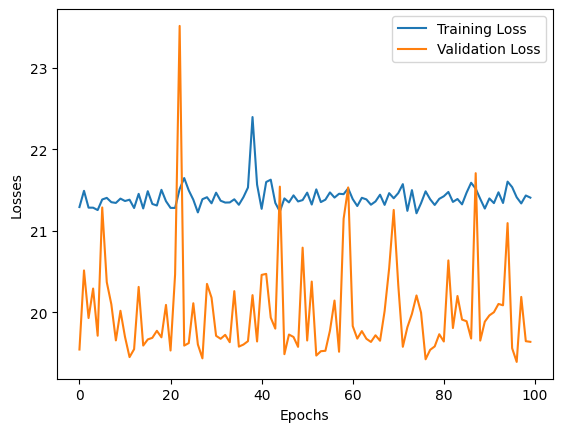

In [51]:
import matplotlib.pyplot as plt

loss_df = pd.DataFrame({
    "Training Loss": train_loss,
    "Validation Loss": eval_loss
})

plt.plot(loss_df["Training Loss"], label = "Training Loss")
plt.plot(loss_df["Validation Loss"], label = "Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Losses")

plt.legend()
plt.show()

In [52]:
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>